## P2.b — Evaluación de LSH en un mes

- **Entrada:** `data/final/` + `data/p2/firmas/`
- Como en lab4 (Act. 02 y 04): ground truth exacto de un mes y precision / recall / F1 de los candidatos LSH para varias `(b, r)`
- Sirve para justificar `(b, r) = (10, 10)` antes de la corrida completa (`c_lsh_pares.ipynb`)

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes y funciones compartidas (`02_P2/p2_funciones.ipynb`)

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
ruta_funciones = str(proyecto / "02_P2" / "p2_funciones.ipynb")
%run $ruta_funciones

final_dir     = proyecto / "data" / "final"
firmas_dir    = proyecto / "data" / "p2" / "firmas"
pares_dir     = proyecto / "data" / "p2" / "pares"
entidades_dir = proyecto / "data" / "p2" / "entidades"

/opt/conda/lib/python3.11/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("p2_b_evaluacion_lsh")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Mes de análisis

- Se cargan el mes y el siguiente (partition pruning). Cambiar `ANIO_CHK, MES_CHK` para revisar otro mes

In [5]:
assert firmas_dir.exists(), f"No se encuentra {firmas_dir}; corre a_firmas_minhash.ipynb"
ANIO_CHK, MES_CHK = 2024, 6

procesos = spark.read.parquet(str(final_dir)).select(*COLS_P2)
firmas   = spark.read.parquet(str(firmas_dir))

if not procesos.where((F.col("anio") == ANIO_CHK) & (F.col("mes") == MES_CHK)).limit(1).count():
    f0 = procesos.select("anio", "mes").distinct().orderBy("anio", "mes").first()
    ANIO_CHK, MES_CHK = f0["anio"], f0["mes"]
    print(f"Mes no disponible; se usa {ANIO_CHK}-{MES_CHK:02d}")

proc_m   = procesos.where(filtro_meses(ANIO_CHK, MES_CHK)).select("ocid", "entidad", "fecha", "anio", "mes", "shingles").cache()
firmas_m = firmas.where(filtro_meses(ANIO_CHK, MES_CHK)).cache()
print(f"{ANIO_CHK}-{MES_CHK:02d} + mes siguiente: {proc_m.count():,} procesos, {firmas_m.count():,} firmas")

2024-06 + mes siguiente: 13,420 procesos, 13,420 firmas


### 2. Ground truth exacto

- Jaccard de **todos** los pares de la misma entidad dentro de la ventana, sin LSH (fuerza bruta, sólo para este mes)

In [6]:
a, b = proc_m.alias("a"), proc_m.alias("b")
cond_gt = ((F.col("a.entidad") == F.col("b.entidad")) & orden_par("a", "b") &
           (F.datediff(F.col("b.fecha"), F.col("a.fecha")) <= VENTANA_DIAS) &
           (F.col("a.anio") == ANIO_CHK) & (F.col("a.mes") == MES_CHK))
t0 = time.time()
gt = (a.join(b, cond_gt).select(F.col("a.ocid").alias("ocid_1"), F.col("b.ocid").alias("ocid_2"),
                                jaccard_exacto(F.col("a.shingles"), F.col("b.shingles")).alias("jaccard")).cache())
n_gt = gt.count(); gt_pos = gt.where(F.col("jaccard") >= UMBRAL).cache(); n_pos = gt_pos.count()
print(f"Pares exactos en la ventana: {n_gt:,} | con Jaccard ≥ {UMBRAL}: {n_pos:,} | {time.time() - t0:.1f} s")

Pares exactos en la ventana: 208,392 | con Jaccard ≥ 0.9: 8,330 | 6.9 s


### 3. LSH por configuración `(b, r)`

- `candidatos` = pares que LSH propone; `FP` se descartan al verificar (cuestan tiempo); `FN` son pares reales que LSH **pierde**

In [7]:
def metricas_lsh(b, r):
    t0 = time.time()
    cands = candidatos_lsh(lsh_bandas(firmas_m, b, r), ANIO_CHK, MES_CHK)
    n_c = cands.count()
    tp = cands.join(gt_pos, ["ocid_1", "ocid_2"]).count()
    fp, fn = n_c - tp, n_pos - tp
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return {"b": b, "r": r, "umbral_lsh": round((1 / b) ** (1 / r), 3), "candidatos": n_c, "GT": n_pos,
            "TP": tp, "FP": fp, "FN": fn, "precision": round(prec, 4), "recall": round(rec, 4), "F1": round(f1, 4), "seg": round(time.time() - t0, 1)}

configs = [(10, 10), (20, 5), (5, 20), (25, 4)]
tabla = pd.DataFrame([metricas_lsh(b_, r_) for b_, r_ in configs])
print(f"Fuerza bruta: {n_gt:,} comparaciones")
tabla

Fuerza bruta: 208,392 comparaciones


,b,r,umbral_lsh,candidatos,GT,TP,FP,FN,precision,recall,F1,seg
0,10,10,0.794,10203,8330,8330,1873,0,0.8164,1.0000,0.8989,5.8
1,20,5,0.549,29545,8330,8330,21215,0,0.2819,1.0000,0.4399,6.7
2,5,20,0.923,8362,8330,8310,52,20,0.9938,0.9976,0.9957,2.5
3,25,4,0.447,47728,8330,8330,39398,0,0.1745,1.0000,0.2972,4.9


- `(10, 10)`: umbral LSH 0.79 < 0.90 → recall ≈ 1 con pocos candidatos. `(5, 20)`: umbral 0.92 → pierde pares del 90–92%. `r` bajo (`(20,5)`, `(25,4)`): muchos más candidatos sin ganar recall
- La columna `candidatos` frente a las comparaciones de fuerza bruta mide cuánto trabajo ahorra LSH

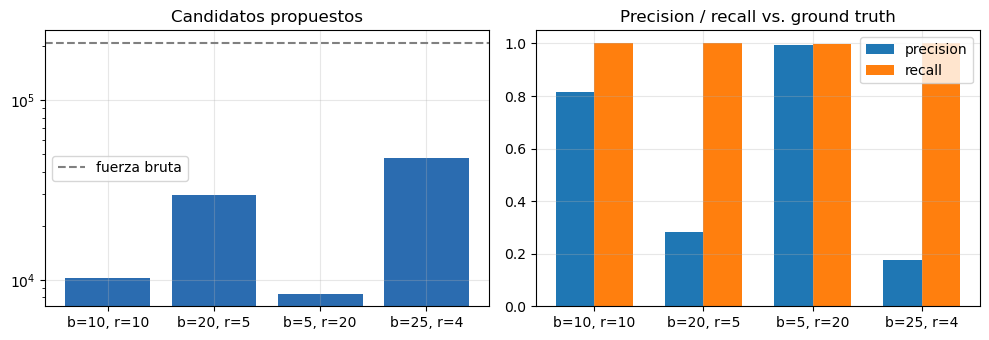

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
x = [f"b={b_}, r={r_}" for b_, r_ in configs]
ax[0].bar(x, tabla["candidatos"], color="#2b6cb0"); ax[0].axhline(n_gt, color="gray", ls="--", label="fuerza bruta"); ax[0].set_yscale("log")
ax[0].set_title("Candidatos propuestos"); ax[0].legend()
w = .35; i = np.arange(len(x))
ax[1].bar(i - w / 2, tabla["precision"], w, label="precision"); ax[1].bar(i + w / 2, tabla["recall"], w, label="recall")
ax[1].set_xticks(i); ax[1].set_xticklabels(x); ax[1].set_title("Precision / recall vs. ground truth"); ax[1].legend()
plt.tight_layout(); plt.show()

### 4. Pares verificados del mes con `(10, 10)`

In [10]:
pares_m = verificar_pares(candidatos_lsh(lsh_bandas(firmas_m), ANIO_CHK, MES_CHK), procesos.where(filtro_meses(ANIO_CHK, MES_CHK)), firmas_m).cache()
n_pm = pares_m.count()
assert n_pm <= n_pos
print(f"Pares ≥ {UMBRAL} vía LSH: {n_pm:,} de {n_pos:,} exactos ({n_pm / max(n_pos, 1):.1%})")
pares_m.orderBy(F.desc("jaccard"), "dias_diferencia").select("entidad", "fecha_1", "fecha_2", "dias_diferencia", "jaccard", "minhash_sim", "tramo_1", "tramo_2", "tramo_suma").show(10, truncate=35)

def monto(x):
    return f"{x:,.0f}" if x is not None else "sin monto"

ej = pares_m.where(~F.col("texto_identico")).orderBy(F.desc("jaccard")).first() or pares_m.first()
if ej:
    print(f"{ej['entidad']} | {ej['fecha_1']:%Y-%m-%d} → {ej['fecha_2']:%Y-%m-%d} ({ej['dias_diferencia']} días) | Jaccard {ej['jaccard']} | MinHash {ej['minhash_sim']}")
    print(f"Montos {monto(ej['monto_final_1'])} + {monto(ej['monto_final_2'])} = {monto(ej['monto_suma'])} ({ej['tramo_1']} + {ej['tramo_2']} → {ej['tramo_suma']})")
    print(f"[1] {ej['descripcion_1'][:250]}\n[2] {ej['descripcion_2'][:250]}")

Pares ≥ 0.9 vía LSH: 8,330 de 8,330 exactos (100.0%)
+-----------------------------------+-------------------+-------------------+---------------+-------+-----------+-----------+-----------+-----------+
|                            entidad|            fecha_1|            fecha_2|dias_diferencia|jaccard|minhash_sim|    tramo_1|    tramo_2| tramo_suma|
+-----------------------------------+-------------------+-------------------+---------------+-------+-----------+-----------+-----------+-----------+
|  MUNICIPALIDAD DISTRITAL DE TORATA|2024-06-20 00:00:00|2024-06-20 00:00:00|              0|    1.0|        1.0|0_sin_monto|0_sin_monto|0_sin_monto|
|INPE-OFICINA GENERAL DE INFRAEST...|2024-06-17 00:00:00|2024-06-17 00:00:00|              0|    1.0|        1.0|      5_>5M|      5_>5M|      5_>5M|
|INSTITUTO VIAL PROVINCIAL MUNICI...|2024-06-11 00:00:00|2024-06-11 00:00:00|              0|    1.0|        1.0| 2_50k-200k| 2_50k-200k| 2_50k-200k|
|ORGANISMO DE EVALUACION Y FISCAL...|2024-06-28

### 5. Cierre

In [11]:
spark.stop()